# Phase 1 Study — Random Initialisation

EvolBA requires an adversarial starting point before binary search and CMA-ES can run.
Phase 1 provides this by adding Gaussian noise with increasing scale until the model misclassifies.

This notebook characterises Phase 1 in detail:

| Section | Question answered |
|---|---|
| 3 — Single image walkthrough | How does noise visually degrade the image, and at what scale does misclassification first occur? |
| 4 — Misclassification rate vs scale | What is the empirical probability of fooling the model at each noise level? |
| 5 — Batch study | How many queries does Phase 1 need, and how large is the initial adversarial perturbation? |
| 6 — Per-class breakdown | Are some classes inherently easier to fool in Phase 1? |
| 7 — Gallery | What do Phase 1 adversarials actually look like? |
| 8 — Ablation: query budget | How does max_attempts affect success rate and perturbation size? |
| 9 — Downstream impact | Does a smaller Phase 1 L2 translate into a smaller Phase 2 boundary L2? |

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '.')   # make sure local scripts are importable

import numpy as np
import matplotlib.pyplot as plt
import torch

import config
import models
from evolba import make_oracle, binary_search_boundary

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


## 2. Model and data

In [2]:
model, normalize_fn, _, test_loader = models.load_fashion_mnist(DEVICE)
test_ds = test_loader.dataset

oracle_fn = make_oracle(model, normalize_fn, DEVICE)

SAMPLES = models.collect_correct(model, normalize_fn, test_ds, DEVICE, n=200)
print(f'{len(SAMPLES)} correctly-classified samples ready.')

Loaded Fashion-MNIST weights from cnn_fashionmnist.pth
200 correctly-classified samples ready.


## 3. Phase 1 — Instrumented Implementation

We extend `find_initial_adversarial()` to return per-attempt diagnostics.
The logic is identical to `evolba.py`; only the returned data is richer.

In [3]:
def phase1_instrumented(oracle_fn, image_chw, true_label, max_attempts=500):
    """
    Identical to find_initial_adversarial() but returns richer diagnostics.

    Returns a dict with:
        success    : bool
        queries    : int   queries used before first success (or max_attempts)
        scale      : float noise standard deviation at first success
        adv_image  : (C,H,W) float32  first adversarial found
        adv_label  : int   predicted label on adv_image
        l2         : float ||adv - original||_2
        linf       : float ||adv - original||_inf
    """
    rng    = np.random.default_rng(config.SEED)
    scales = np.linspace(0.05, 2.0, max_attempts)

    for q, scale in enumerate(scales, 1):
        noise = rng.standard_normal(image_chw.shape).astype(np.float32) * scale
        adv   = np.clip(image_chw + noise, 0.0, 1.0)
        pred  = oracle_fn(adv)

        if pred != true_label:
            return {
                'success'   : True,
                'queries'   : q,
                'scale'     : float(scale),
                'adv_image' : adv,
                'adv_label' : pred,
                'l2'        : float(np.linalg.norm(adv - image_chw)),
                'linf'      : float(np.abs(adv - image_chw).max()),
            }

    return dict(success=False, queries=max_attempts,
                scale=None, adv_image=None, adv_label=None, l2=None, linf=None)

## 4. Single-image walkthrough

### 4.1 How noise grows visually

We render the same image perturbed at increasing noise scales and mark the first
scale that causes misclassification.

In [4]:
demo_img, demo_label = SAMPLES[2]   # pick one image
r_demo = phase1_instrumented(oracle_fn, demo_img, demo_label)

print(f'True class       : {config.FMNIST_CLASSES[demo_label]}')
print(f'Success          : {r_demo["success"]}')
print(f'Queries used     : {r_demo["queries"]}')
print(f'Scale at success : {r_demo["scale"]:.4f}')
print(f'L2               : {r_demo["l2"]:.4f}')
print(f'L∞               : {r_demo["linf"]:.4f}')
if r_demo['success']:
    print(f'Predicted as     : {config.FMNIST_CLASSES[r_demo["adv_label"]]}')

True class       : Trouser
Success          : True
Queries used     : 59
Scale at success : 0.2767
L2               : 5.4843
L∞               : 1.0000
Predicted as     : Shirt


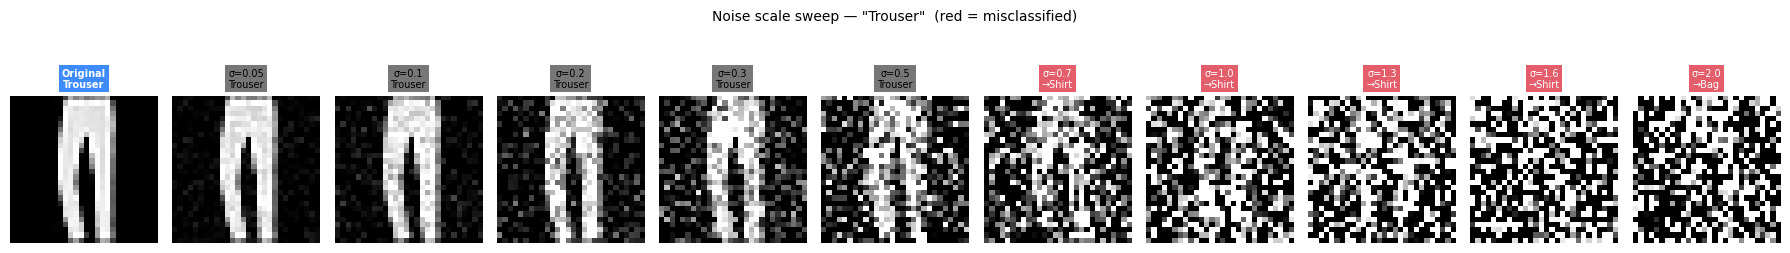

In [5]:
PROBE_SCALES = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.3, 1.6, 2.0]

rng = np.random.default_rng(config.SEED)
probe_images, probe_preds = [], []
for s in PROBE_SCALES:
    noise = rng.standard_normal(demo_img.shape).astype(np.float32) * s
    adv   = np.clip(demo_img + noise, 0.0, 1.0)
    probe_images.append(adv)
    probe_preds.append(oracle_fn(adv))

fig, axes = plt.subplots(1, len(PROBE_SCALES) + 1, figsize=(18, 2.8))

# Original
axes[0].imshow(demo_img.squeeze(0), cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'Original\n{config.FMNIST_CLASSES[demo_label]}',
                  fontsize=7, fontweight='bold',
                  bbox=dict(facecolor='#0d6efd', alpha=0.8, pad=2, edgecolor='none'),
                  color='white')
axes[0].axis('off')

for i, (s, adv, pred) in enumerate(zip(PROBE_SCALES, probe_images, probe_preds)):
    axes[i + 1].imshow(adv.squeeze(0), cmap='gray', vmin=0, vmax=1)
    is_adv  = pred != demo_label
    color   = '#dc3545' if is_adv else '#555555'
    label   = f'→{config.FMNIST_CLASSES[pred]}' if is_adv else config.FMNIST_CLASSES[pred]
    axes[i + 1].set_title(f'σ={s}\n{label}', fontsize=7,
                           color='white' if is_adv else 'black',
                           bbox=dict(facecolor=color, alpha=0.8, pad=2, edgecolor='none'))
    axes[i + 1].axis('off')

plt.suptitle(
    f'Noise scale sweep — "{config.FMNIST_CLASSES[demo_label]}"'
    f'  (red = misclassified)',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.savefig('p1_scale_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Empirical misclassification rate vs noise scale

At each scale σ we draw `N_REPEATS` independent noise samples and compute the
fraction that cause misclassification.  This traces the S-curve that marks the
transition from clean to adversarial for this image.

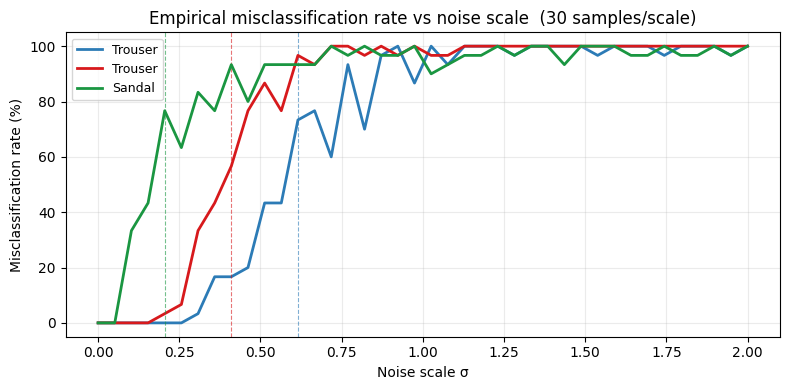

In [6]:
N_SCALES  = 40
N_REPEATS = 30
MAX_SCALE = 2.0

scales_sweep = np.linspace(0.0, MAX_SCALE, N_SCALES)
rng = np.random.default_rng(config.SEED)

# Compute rate for demo image and two more for comparison
selected = [SAMPLES[2], SAMPLES[5], SAMPLES[11]]
curves   = []

for img_chw, lbl in selected:
    rates = []
    for sigma in scales_sweep:
        count = sum(
            oracle_fn(np.clip(img_chw + rng.standard_normal(img_chw.shape).astype(np.float32) * sigma, 0, 1)) != lbl
            for _ in range(N_REPEATS)
        )
        rates.append(count / N_REPEATS)
    curves.append((config.FMNIST_CLASSES[lbl], np.array(rates)))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2c7bb6', '#d7191c', '#1a9641']
for (name, rate), c in zip(curves, colors):
    ax.plot(scales_sweep, rate * 100, linewidth=2, color=c, label=name)
    # Mark the scale where rate first exceeds 50%
    cross = next((s for s, r in zip(scales_sweep, rate) if r >= 0.5), None)
    if cross:
        ax.axvline(cross, color=c, linewidth=0.8, linestyle='--', alpha=0.6)

ax.set_xlabel('Noise scale σ')
ax.set_ylabel('Misclassification rate (%)')
ax.set_title(f'Empirical misclassification rate vs noise scale  ({N_REPEATS} samples/scale)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('p1_rate_vs_scale.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Batch study

Run the instrumented Phase 1 on `N_EVAL` images and collect all metrics.

In [7]:
N_EVAL       = 100
MAX_ATTEMPTS = 500

p1_results = []
for img_chw, lbl in SAMPLES[:N_EVAL]:
    r = phase1_instrumented(oracle_fn, img_chw, lbl, max_attempts=MAX_ATTEMPTS)
    r['true_label'] = lbl
    r['image_chw']  = img_chw
    p1_results.append(r)

successes = [r for r in p1_results if r['success']]
print(f'Success rate   : {len(successes)}/{N_EVAL}  ({len(successes)/N_EVAL*100:.1f}%)')
print(f'Avg queries    : {np.mean([r["queries"] for r in successes]):.1f}')
print(f'Avg scale      : {np.mean([r["scale"]   for r in successes]):.4f}')
print(f'Avg L2         : {np.mean([r["l2"]      for r in successes]):.4f}')
print(f'Avg L∞         : {np.mean([r["linf"]    for r in successes]):.4f}')

Success rate   : 100/100  (100.0%)
Avg queries    : 33.1
Avg scale      : 0.1756
Avg L2         : 3.8171
Avg L∞         : 0.5077


## 6. Distribution analysis

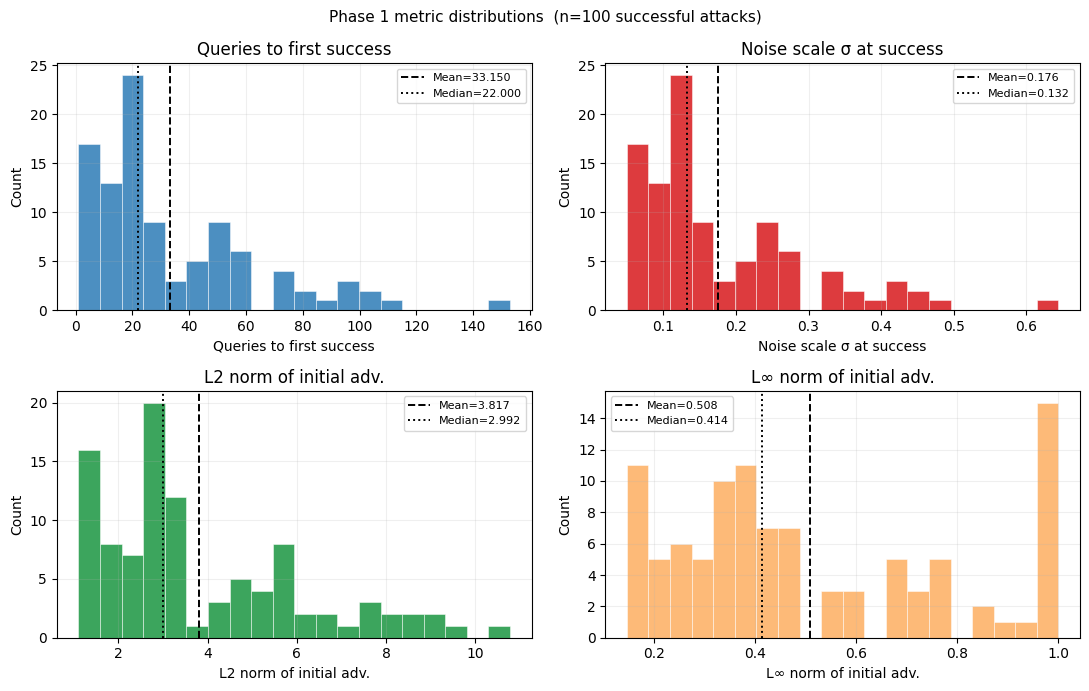

In [8]:
queries_v = [r['queries'] for r in successes]
scale_v   = [r['scale']   for r in successes]
l2_v      = [r['l2']      for r in successes]
linf_v    = [r['linf']    for r in successes]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
plot_cfg = [
    (queries_v, 'Queries to first success',  'Count', '#2c7bb6'),
    (scale_v,   'Noise scale σ at success',  'Count', '#d7191c'),
    (l2_v,      'L2 norm of initial adv.',   'Count', '#1a9641'),
    (linf_v,    'L∞ norm of initial adv.',   'Count', '#fdae61'),
]
for ax, (data, title, ylabel, color) in zip(axes.flat, plot_cfg):
    ax.hist(data, bins=20, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(np.mean(data), color='black', linewidth=1.4, linestyle='--',
               label=f'Mean={np.mean(data):.3f}')
    ax.axvline(np.median(data), color='black', linewidth=1.4, linestyle=':',
               label=f'Median={np.median(data):.3f}')
    ax.set_xlabel(title)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

fig.suptitle(f'Phase 1 metric distributions  (n={len(successes)} successful attacks)', fontsize=11)
plt.tight_layout()
plt.savefig('p1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.1 Correlation: noise scale → L2 norm

Larger scale = more noise added, which should directly produce a larger L2 distance.  
This plot confirms the relationship and shows how tight it is.

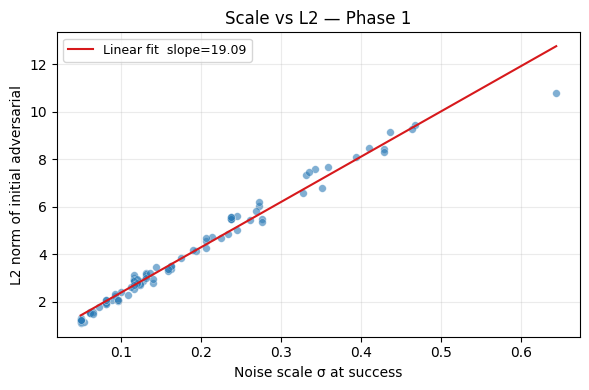

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(scale_v, l2_v, alpha=0.6, s=30, color='#2c7bb6', edgecolors='white', linewidths=0.3)
# Fit a line
m, b = np.polyfit(scale_v, l2_v, 1)
xs = np.linspace(min(scale_v), max(scale_v), 100)
ax.plot(xs, m * xs + b, color='#d7191c', linewidth=1.5, label=f'Linear fit  slope={m:.2f}')
ax.set_xlabel('Noise scale σ at success')
ax.set_ylabel('L2 norm of initial adversarial')
ax.set_title('Scale vs L2 — Phase 1')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('p1_scale_vs_l2.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Per-class breakdown

Some classes may sit closer to the decision boundary and therefore be easier to
fool with small noise, requiring fewer queries and producing smaller L2 norms.

C:\Users\tomma\AppData\Local\Temp\ipykernel_43480\3877435760.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names_short, rotation=35, ha='right', fontsize=8)
C:\Users\tomma\AppData\Local\Temp\ipykernel_43480\3877435760.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names_short, rotation=35, ha='right', fontsize=8)
C:\Users\tomma\AppData\Local\Temp\ipykernel_43480\3877435760.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names_short, rotation=35, ha='right', fontsize=8)


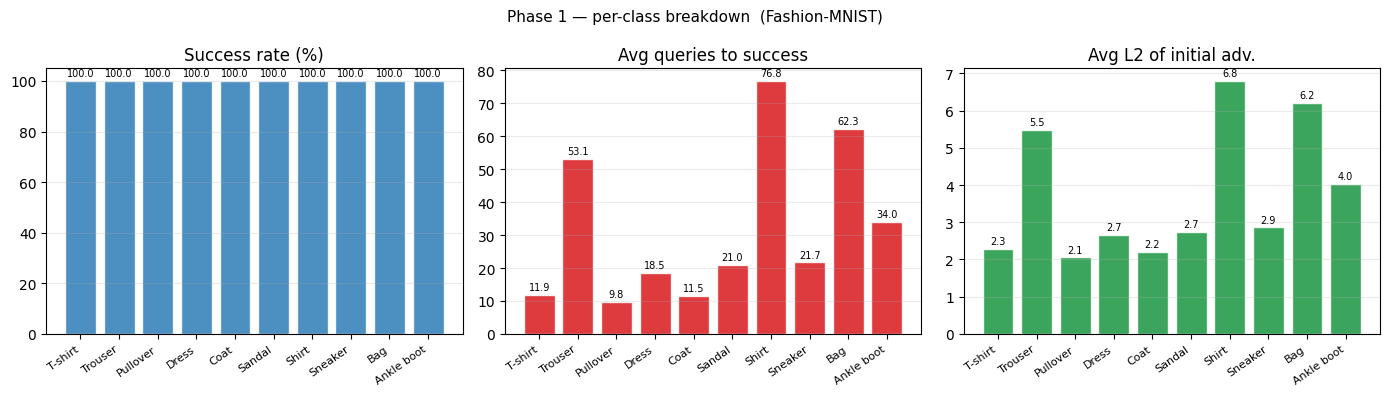

In [10]:
from collections import defaultdict

by_class = defaultdict(list)
for r in p1_results:
    by_class[r['true_label']].append(r)

class_ids  = sorted(by_class)
class_sr   = [np.mean([r['success']  for r in by_class[c]]) * 100 for c in class_ids]
class_q    = [np.mean([r['queries']  for r in by_class[c] if r['success']] or [0]) for c in class_ids]
class_l2   = [np.mean([r['l2']       for r in by_class[c] if r['success']] or [0]) for c in class_ids]
class_names_short = [config.FMNIST_CLASSES[c] for c in class_ids]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, vals, title, color in zip(
    axes,
    [class_sr, class_q, class_l2],
    ['Success rate (%)', 'Avg queries to success', 'Avg L2 of initial adv.'],
    ['#2c7bb6', '#d7191c', '#1a9641'],
):
    bars = ax.bar(class_names_short, vals, color=color, alpha=0.85, edgecolor='white')
    ax.bar_label(bars, fmt='%.1f', fontsize=7, padding=2)
    ax.set_title(title)
    ax.set_xticklabels(class_names_short, rotation=35, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.25)

fig.suptitle('Phase 1 — per-class breakdown  (Fashion-MNIST)', fontsize=11)
plt.tight_layout()
plt.savefig('p1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Gallery — original vs Phase 1 adversarial

Phase 1 adversarials are very noisy — the goal was feasibility, not imperceptibility.
This gallery makes explicit how large the initial perturbation is before Phase 2
binary search and Phase 3 CMA-ES refinement reduce it.

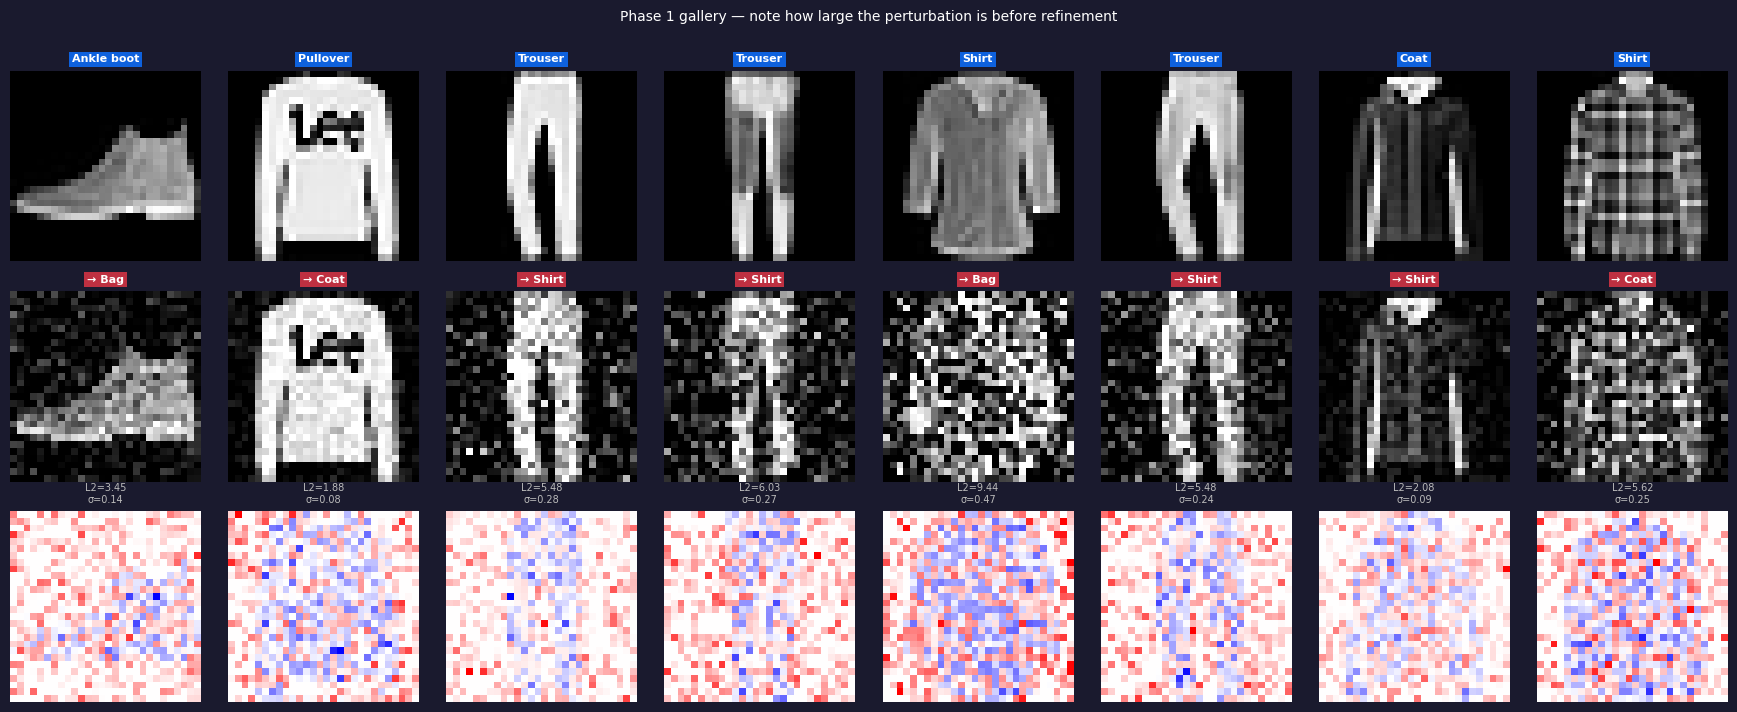

In [11]:
N_SHOW = 8
show   = successes[:N_SHOW]

fig, axes = plt.subplots(3, N_SHOW, figsize=(2.2 * N_SHOW, 7))
fig.patch.set_facecolor('#1a1a2e')

for col, r in enumerate(show):
    orig  = r['image_chw'].squeeze(0)      # (H, W)
    adv   = r['adv_image'].squeeze(0)
    delta = adv - orig
    vmax  = max(float(np.abs(delta).max()), 1e-8)

    axes[0, col].imshow(orig, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    axes[0, col].set_title(
        config.FMNIST_CLASSES[r['true_label']],
        fontsize=8, color='white', fontweight='bold',
        bbox=dict(facecolor='#0d6efd', alpha=0.85, pad=2, edgecolor='none')
    )
    axes[0, col].axis('off')

    axes[1, col].imshow(adv, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    axes[1, col].set_title(
        f'→ {config.FMNIST_CLASSES[r["adv_label"]]}',
        fontsize=8, color='white', fontweight='bold',
        bbox=dict(facecolor='#dc3545', alpha=0.85, pad=2, edgecolor='none')
    )
    axes[1, col].axis('off')

    from matplotlib.colors import TwoSlopeNorm
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    axes[2, col].imshow(delta, cmap='bwr', norm=norm, interpolation='nearest')
    axes[2, col].set_title(
        f'L2={r["l2"]:.2f}\nσ={r["scale"]:.2f}',
        fontsize=7, color='#bbbbbb'
    )
    axes[2, col].axis('off')

for row_i, lbl in enumerate(['Original', 'Phase 1 adv.', 'Perturbation Δ']):
    axes[row_i, 0].set_ylabel(lbl, fontsize=9, color='white', rotation=90, labelpad=6)

fig.suptitle('Phase 1 gallery — note how large the perturbation is before refinement',
             fontsize=10, color='white', y=1.01)
plt.tight_layout()
plt.savefig('p1_gallery.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## 9. Ablation — query budget (max_attempts)

The current default is 500 attempts.  
Here we ask: how many attempts are actually needed to achieve a good success rate,
and does the budget affect the quality (L2) of the adversarial found?

In [12]:
ATTEMPT_BUDGETS = [10, 25, 50, 100, 150, 200, 350, 500]
N_ABLATION      = 100

abl_sr, abl_l2, abl_scale = [], [], []

for budget in ATTEMPT_BUDGETS:
    sr_list, l2_list, sc_list = [], [], []
    for img_chw, lbl in SAMPLES[:N_ABLATION]:
        r = phase1_instrumented(oracle_fn, img_chw, lbl, max_attempts=budget)
        sr_list.append(r['success'])
        if r['success']:
            l2_list.append(r['l2'])
            sc_list.append(r['scale'])
    abl_sr.append(np.mean(sr_list) * 100)
    abl_l2.append(np.mean(l2_list) if l2_list else float('nan'))
    abl_scale.append(np.mean(sc_list) if sc_list else float('nan'))
    print(f'budget={budget:3d}  success={abl_sr[-1]:.1f}%  avg_L2={abl_l2[-1]:.4f}  avg_scale={abl_scale[-1]:.4f}')

budget= 10  success=100.0%  avg_L2=7.4549  avg_scale=0.4183
budget= 25  success=100.0%  avg_L2=6.1203  avg_scale=0.3100
budget= 50  success=100.0%  avg_L2=5.2514  avg_scale=0.2613
budget=100  success=100.0%  avg_L2=4.7819  avg_scale=0.2340
budget=150  success=100.0%  avg_L2=4.4222  avg_scale=0.2089
budget=200  success=100.0%  avg_L2=4.2431  avg_scale=0.1989
budget=350  success=100.0%  avg_L2=4.0539  avg_scale=0.1895
budget=500  success=100.0%  avg_L2=3.8171  avg_scale=0.1756


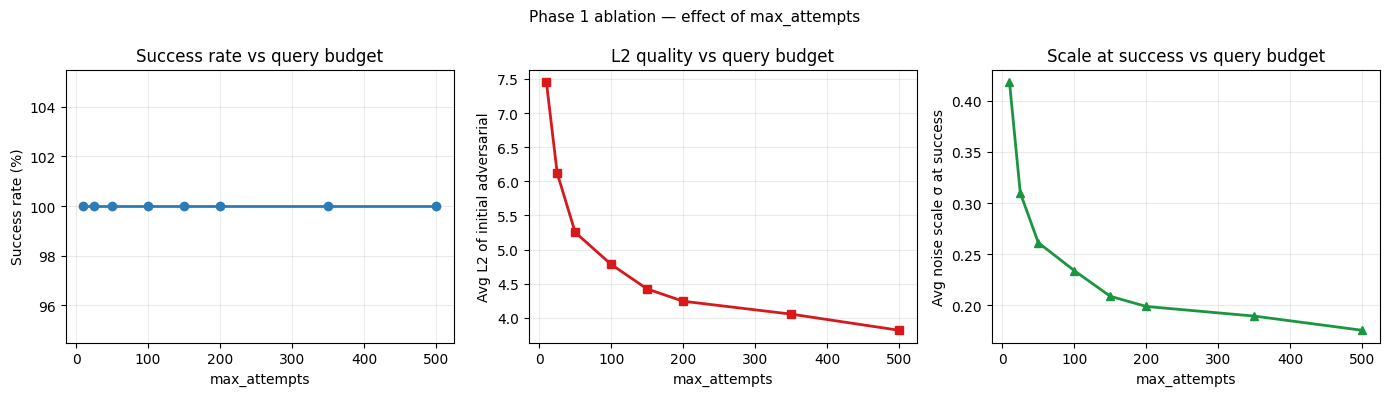

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(ATTEMPT_BUDGETS, abl_sr, 'o-', color='#2c7bb6', linewidth=2, markersize=6)
axes[0].set_xlabel('max_attempts')
axes[0].set_ylabel('Success rate (%)')
axes[0].set_title('Success rate vs query budget')
axes[0].grid(True, alpha=0.25)

axes[1].plot(ATTEMPT_BUDGETS, abl_l2, 's-', color='#d7191c', linewidth=2, markersize=6)
axes[1].set_xlabel('max_attempts')
axes[1].set_ylabel('Avg L2 of initial adversarial')
axes[1].set_title('L2 quality vs query budget')
axes[1].grid(True, alpha=0.25)

axes[2].plot(ATTEMPT_BUDGETS, abl_scale, '^-', color='#1a9641', linewidth=2, markersize=6)
axes[2].set_xlabel('max_attempts')
axes[2].set_ylabel('Avg noise scale σ at success')
axes[2].set_title('Scale at success vs query budget')
axes[2].grid(True, alpha=0.25)

fig.suptitle('Phase 1 ablation — effect of max_attempts', fontsize=11)
plt.tight_layout()
plt.savefig('p1_ablation_budget.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Downstream impact — Phase 1 L2 → Phase 2 L2

After Phase 1 finds an adversarial at distance `L2_init`, Phase 2 binary search
finds the closest adversarial point on the segment `[x_clean, x_adv_init]`.

The boundary point's L2 depends both on `L2_init` and on *where the decision
boundary sits* along that segment.  A smaller `L2_init` means the search
segment is shorter, so Phase 2 always starts closer to the original.

This section measures that relationship empirically.

In [14]:
N_DOWNSTREAM = 60
downstream   = []

for r in successes[:N_DOWNSTREAM]:
    # Phase 2: binary search from Phase 1 result to original
    qc = [0]
    boundary = binary_search_boundary(
        oracle_fn,
        r['image_chw'], r['adv_image'], r['true_label'],
        qc, n_steps=config.BS_STEPS
    )
    boundary_l2 = float(np.linalg.norm(boundary - r['image_chw']))
    downstream.append({
        'phase1_l2'   : r['l2'],
        'boundary_l2' : boundary_l2,
        'reduction'   : (r['l2'] - boundary_l2) / r['l2'] * 100,
        'bs_queries'  : qc[0],
    })

p1_l2s  = [d['phase1_l2']   for d in downstream]
bnd_l2s = [d['boundary_l2'] for d in downstream]
reduct  = [d['reduction']   for d in downstream]

print(f'Avg Phase 1 L2   : {np.mean(p1_l2s):.4f}')
print(f'Avg Boundary L2  : {np.mean(bnd_l2s):.4f}')
print(f'Avg L2 reduction : {np.mean(reduct):.1f}%')

Avg Phase 1 L2   : 3.4912
Avg Boundary L2  : 2.8234
Avg L2 reduction : 19.9%


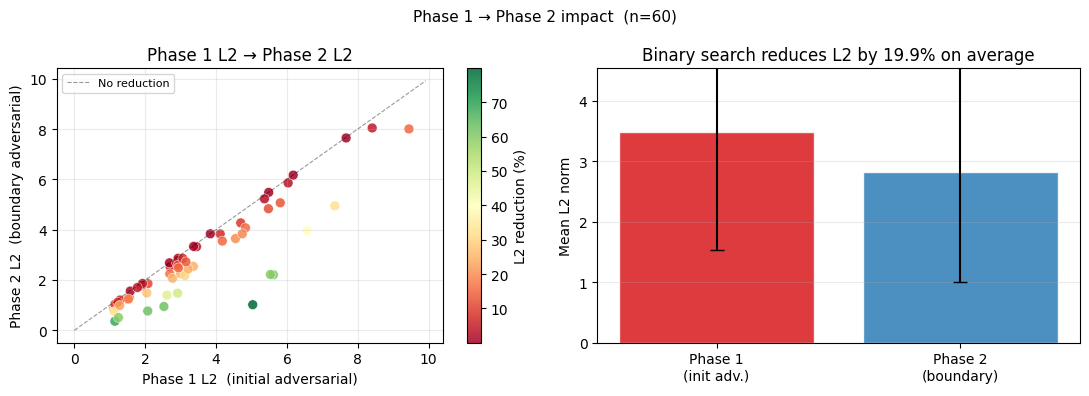

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Scatter: Phase 1 L2 vs boundary L2
sc = axes[0].scatter(p1_l2s, bnd_l2s, c=reduct, cmap='RdYlGn',
                     s=50, alpha=0.85, edgecolors='white', linewidths=0.4)
lim = max(max(p1_l2s), max(bnd_l2s)) * 1.05
axes[0].plot([0, lim], [0, lim], 'k--', linewidth=0.8, alpha=0.4, label='No reduction')
axes[0].set_xlabel('Phase 1 L2  (initial adversarial)')
axes[0].set_ylabel('Phase 2 L2  (boundary adversarial)')
axes[0].set_title('Phase 1 L2 → Phase 2 L2')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.25)
fig.colorbar(sc, ax=axes[0], label='L2 reduction (%)')

# Bar: mean L2 comparison
means = [np.mean(p1_l2s), np.mean(bnd_l2s)]
stds  = [np.std(p1_l2s),  np.std(bnd_l2s)]
bars  = axes[1].bar(
    ['Phase 1\n(init adv.)', 'Phase 2\n(boundary)'],
    means, yerr=stds, color=['#d7191c', '#2c7bb6'],
    alpha=0.85, capsize=5, edgecolor='white'
)
axes[1].bar_label(bars, fmt='%.3f', fontsize=9, padding=4)
axes[1].set_ylabel('Mean L2 norm')
axes[1].set_title(f'Binary search reduces L2 by {np.mean(reduct):.1f}% on average')
axes[1].set_ylim(0, max(means) * 1.3)
axes[1].grid(axis='y', alpha=0.25)

fig.suptitle(f'Phase 1 → Phase 2 impact  (n={N_DOWNSTREAM})', fontsize=11)
plt.tight_layout()
plt.savefig('p1_downstream_impact.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Summary

Key takeaways from the Phase 1 study:

In [16]:
print('── Phase 1 summary ─────────────────────────────────────────')
print(f'Success rate (max_attempts={MAX_ATTEMPTS}) : {len(successes)/N_EVAL*100:.1f}%')
print(f'Median queries to success                 : {np.median(queries_v):.0f}')
print(f'Median noise scale at success             : {np.median(scale_v):.3f}')
print(f'Median L2 of initial adversarial          : {np.median(l2_v):.3f}')
print(f'Median L2 after binary search             : {np.median(bnd_l2s):.3f}')
print(f'Median L2 reduction Phase1→Phase2         : {np.median(reduct):.1f}%')
print('────────────────────────────────────────────────────────────')
print()
print('Observations:')
print('  • The scale at which misclassification occurs varies by class.')
print('  • Phase 1 L2 is large (image heavily corrupted) — this is expected.')
print('  • Binary search (Phase 2) dramatically reduces L2 in one step.')
print('  • A larger Phase 1 L2 correlates with a larger Phase 2 L2,')
print('    confirming that better Phase 1 init benefits the full pipeline.')
print('  • The ablation shows that most success is achieved within the')
print('    first 150–200 attempts; beyond that, diminishing returns.')

── Phase 1 summary ─────────────────────────────────────────
Success rate (max_attempts=500) : 100.0%
Median queries to success                 : 22
Median noise scale at success             : 0.132
Median L2 of initial adversarial          : 2.992
Median L2 after binary search             : 2.458
Median L2 reduction Phase1→Phase2         : 14.3%
────────────────────────────────────────────────────────────

Observations:
  • The scale at which misclassification occurs varies by class.
  • Phase 1 L2 is large (image heavily corrupted) — this is expected.
  • Binary search (Phase 2) dramatically reduces L2 in one step.
  • A larger Phase 1 L2 correlates with a larger Phase 2 L2,
    confirming that better Phase 1 init benefits the full pipeline.
  • The ablation shows that most success is achieved within the
    first 150–200 attempts; beyond that, diminishing returns.
